# POS Phase Results
This notebook summarizes each phase (1-4) from the JSON results and highlights best models, parameter impacts, and per-tag performance.

## Rating configuration (no duplicate functions)

### Set this to either:
  - a column name in the DataFrame, e.g. "f1" or "token_accuracy"
  - a formula combining columns, e.g. "0.7*f1 + 0.3*best_val_accuracy"

### Examples:
  - RATING_SPEC = "f1"
  - RATING_SPEC = "0.7*f1 + 0.3*best_val_accuracy"
  - RATING_SPEC = "f1 - 0.000001*num_params"  # tiny size penalty (if num_params exists)

In [122]:
RATING_SPEC = "f1"

In [123]:
from __future__ import annotations

import hashlib
import json
import math
from pathlib import Path
from typing import Any, Iterable

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import pandas as pd


def _rating_label(rating_spec: str | None) -> str:
    spec = (rating_spec or "").strip()
    return spec if spec else "f1"


def _ensure_rating_column(df: pd.DataFrame, rating_spec: str | None) -> pd.DataFrame:
    """Return a copy of df with numeric `_rating`.

    - If `rating_spec` matches a column name, uses that.
    - Otherwise treats it as an expression over existing columns.
    """

    if df.empty:
        return df

    rating_spec = (rating_spec or "").strip() or "f1"

    out = df.copy()
    if rating_spec in out.columns:
        out["_rating"] = pd.to_numeric(out[rating_spec], errors="coerce")
        return out

    local = {c: pd.to_numeric(out[c], errors="coerce") for c in out.columns}
    try:
        rating = pd.eval(rating_spec, local_dict=local, engine="python")
    except Exception as e:
        raise ValueError(
            f"Invalid RATING_SPEC: {rating_spec!r}. "
            "Use a column name (e.g. 'f1') or an expression over columns (e.g. '0.7*f1 + 0.3*best_val_accuracy')."
        ) from e

    out["_rating"] = pd.to_numeric(rating, errors="coerce")
    return out


def _find_results_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd / "resources" / "results", cwd.parent / "resources" / "results"]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


RESULTS_ROOT = _find_results_root()


def _phase_dir(phase_name: str) -> Path:
    return RESULTS_ROOT / phase_name


def _safe_read_json(path: Path) -> dict[str, Any] | list[Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def _metric(model: dict[str, Any], key: str) -> float:
    value = model.get(key)
    if isinstance(value, (int, float)):
        return float(value)

    metrics = model.get("test_metrics", {})
    nested = metrics.get(key)
    if isinstance(nested, (int, float)):
        return float(nested)

    if key == "accuracy":
        nested = metrics.get("token_accuracy")
        if isinstance(nested, (int, float)):
            return float(nested)

    return float("nan")


def load_phase_results(phase_name: str) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    phase_dir = _phase_dir(phase_name)
    if not phase_dir.exists():
        raise FileNotFoundError(f"No results directory found for {phase_name}: {phase_dir}")

    summary_path = phase_dir / "summary.json"
    if summary_path.exists():
        summary_raw = _safe_read_json(summary_path)
        summary = summary_raw if isinstance(summary_raw, dict) else {"config_name": phase_name}
        result_files = summary.get("result_files", [])
        if not isinstance(result_files, list):
            result_files = []
    else:
        result_files = [p.name for p in sorted(phase_dir.glob("*.json")) if p.name != "summary.json"]
        summary = {
            "config_name": phase_name,
            "config_path": None,
            "total_models": len(result_files),
            "result_files": result_files,
        }

    models: list[dict[str, Any]] = []
    for file_name in result_files:
        file_path = phase_dir / file_name
        if not file_path.exists():
            continue
        try:
            model_result = _safe_read_json(file_path)
        except Exception:
            continue
        if isinstance(model_result, dict):
            models.append(model_result)

    return summary, models


def _filter_by_arch(models: list[dict[str, Any]], model_type: str) -> list[dict[str, Any]]:
    return [m for m in models if m.get("model_type") == model_type]


def _config_fingerprint(config: dict[str, Any]) -> str:
    if not isinstance(config, dict):
        return ""

    ignore = {
        "name",
        "seed",
        "runs-count",
        "run_count",
        "run_index",
        "priority",
    }

    normalized: dict[str, Any] = {}
    for key, value in config.items():
        if key in ignore:
            continue
        if isinstance(value, (str, int, float, bool)) or value is None:
            normalized[key] = value

    blob = json.dumps(normalized, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
    return hashlib.sha1(blob.encode("utf-8")).hexdigest()[:12]


def models_frame(models: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for model in models:
        cfg = model.get("config", {})
        if not isinstance(cfg, dict):
            cfg = {}

        row: dict[str, Any] = {
            "name": model.get("name"),
            "model_type": model.get("model_type"),
            "run_index": model.get("run_index"),
            "run_seed": model.get("run_seed"),
            "config_id": _config_fingerprint(cfg),
            "num_params": model.get("num_params"),
            "train_time_sec": model.get("train_time_sec"),
            "epochs_ran": model.get("epochs_ran"),
            "best_val_accuracy": model.get("best_val_accuracy"),
            "f1": _metric(model, "f1"),
            "token_accuracy": _metric(model, "token_accuracy"),
        }

        # Include all config fields so the leaderboard can show *all tuning params*
        # (not just numeric ones).
        for key, value in cfg.items():
            if key in {"name", "priority", "runs-count", "run_count", "run_index", "seed"}:
                continue

            if isinstance(value, (int, float, str, bool)) or value is None:
                row[key] = value
            elif isinstance(value, (list, dict)):
                try:
                    row[key] = json.dumps(value, sort_keys=True, ensure_ascii=False)
                except Exception:
                    row[key] = str(value)
            else:
                row[key] = str(value)

        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    drop_cols = {
        "seed",
        "run_index",
        "run_count",
        "runs-count",
        "vocab_size",
        "num_tags",
        "sentences_config",
    }

    for col in list(df.columns):
        if col in drop_cols:
            df = df.drop(columns=[col])

    return df


def leaderboard(df: pd.DataFrame, top_n: int = 10, *, rating_spec: str | None = None) -> pd.DataFrame:
    """Return a top-N table sorted by a numeric rating.

    For your current workflow: pass rating_spec='best_val_accuracy' to get the best-trained
    models by validation accuracy, *and* this table will include all config/tuning columns so
    you can see exactly which tuning settings produced the top results.
    """
    if df.empty:
        return df

    rating_spec = rating_spec or RATING_SPEC
    rating_label = _rating_label(rating_spec)

    df2 = _ensure_rating_column(df, rating_spec)

    view = df2.copy()
    view[rating_label] = view["_rating"]

    fixed_cols = [
        c
        for c in [
            "name",
            "model_type",
            "config_id",
            rating_label,
            "best_val_loss",
            "f1",
            "token_accuracy",
            "num_params",
            "train_time_sec",
            "epochs_ran",
        ]
        if c in view.columns
    ]

    fixed_set = set(fixed_cols)
    ignore = {"_rating", "run_index", "run_seed"}
    tuning_cols: list[str] = []
    for c in view.columns:
        if c in fixed_set or c in ignore:
            continue
        if c.startswith("_"):
            continue
        if int(view[c].notna().sum()) == 0:
            continue
        tuning_cols.append(c)

    cols = fixed_cols + sorted(tuning_cols)
    return view.sort_values("_rating", ascending=False)[cols].head(top_n)


def _pick_color_column(df: pd.DataFrame) -> tuple[str | None, str | None, bool]:
    candidates: list[tuple[str, str, bool]] = [
        ("lr", "log10(lr)", True),
        ("dropout", "dropout", False),
        ("batch_size", "batch_size", False),
        ("num_layers", "num_layers", False),
        ("num_heads", "num_heads", False),
        ("lstm_units", "lstm_units", False),
        ("embed_dim", "embed_dim", False),
    ]

    for col, label, log_scale in candidates:
        if col in df.columns and df[col].nunique(dropna=True) > 1 and pd.api.types.is_numeric_dtype(df[col]):
            return col, label, log_scale

    return None, None, False


def plot_tradeoff(df: pd.DataFrame, title: str, *, rating_spec: str | None = None) -> None:
    if df.empty:
        print("No data available for tradeoff plot.")
        return

    rating_spec = rating_spec or RATING_SPEC
    rating_label = _rating_label(rating_spec)

    df2 = _ensure_rating_column(df, rating_spec)

    if "best_val_accuracy" not in df2.columns:
        print("Missing required column for tradeoff plot: best_val_accuracy")
        return

    plot_df = df2.dropna(subset=["best_val_accuracy", "_rating"]).copy()
    if plot_df.empty:
        print("No non-null (best_val_accuracy, rating) points to plot.")
        return

    if "num_params" in plot_df.columns and pd.api.types.is_numeric_dtype(plot_df["num_params"]):
        size = plot_df["num_params"].fillna(plot_df["num_params"].median()).astype(float)
        size = (size**0.5) / (size**0.5).max() * 220
        size = size.clip(lower=30)
    else:
        size = 70

    color_col, color_label, color_is_log = _pick_color_column(plot_df)
    if color_col is not None:
        color_raw = plot_df[color_col].astype(float)
        if color_is_log:
            color = color_raw.clip(lower=1e-8).map(lambda x: math.log10(x))
        else:
            color = color_raw
        cmap = "viridis"
    else:
        color = "tab:blue"
        cmap = None

    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        plot_df["best_val_accuracy"],
        plot_df["_rating"],
        s=size,
        c=color,
        cmap=cmap,
        alpha=0.82,
        linewidths=0.0,
    )

    pareto_df = plot_df.sort_values("best_val_accuracy", ascending=True)
    best_y = float("-inf")
    front_x: list[float] = []
    front_y: list[float] = []
    for _, row in pareto_df.iterrows():
        y = float(row["_rating"])
        if y > best_y:
            best_y = y
            front_x.append(float(row["best_val_accuracy"]))
            front_y.append(y)

    if len(front_x) >= 2:
        ax.plot(front_x, front_y, color="black", linewidth=1.5, alpha=0.8)

    top = plot_df.sort_values("_rating", ascending=False).head(5)
    for _, row in top.iterrows():
        label = str(row.get("config_id") or "") or "top"
        ax.annotate(
            label,
            (float(row["best_val_accuracy"]), float(row["_rating"])),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9,
            alpha=0.9,
        )

    ax.set_title(title)
    ax.set_xlabel("best_val_accuracy")
    ax.set_ylabel(rating_label)
    ax.grid(True, alpha=0.25)

    if color_col is not None:
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label(color_label or color_col)

    plt.tight_layout()
    plt.show()


def _is_noise_param(col: str) -> bool:
    if "seed" in col:
        return True
    if col.startswith("run_"):
        return True
    if "parent" in col:
        return True
    if col.endswith("_rank"):
        return True
    return False


def plot_top_param_correlations(
    df: pd.DataFrame,
    *,
    metric_col: str,
    metric_label: str,
    title: str,
    max_params: int = 12,
 ) -> None:
    """Robust Pearson correlations against `metric_col`.

    Handles duplicate column names (which make `df[col]` a DataFrame).
    """

    if df.empty or metric_col not in df.columns:
        print("No data available for correlation plot.")
        return

    def _as_series(x: object) -> pd.Series:
        if isinstance(x, pd.Series):
            return x
        if isinstance(x, pd.DataFrame):
            return x.iloc[:, 0]
        return pd.Series(dtype=float)

    numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    ignore = {
        "best_val_accuracy",
        "f1",
        "token_accuracy",
        "train_time_sec",
        "epochs_ran",
        "num_params",
        "maxlen",
        "epochs",
        "patience",
        "priority",
        "sentences",
    }

    params = [
        c
        for c in numeric
        if c != metric_col and c not in ignore and not _is_noise_param(c) and df[c].nunique(dropna=True) > 1
    ]

    if not params:
        print("No varying numeric hyperparameters to correlate.")
        return

    corrs: list[tuple[str, float]] = []
    for col in params:
        s = df[[col, metric_col]].dropna()
        if len(s) < 3:
            continue

        x = _as_series(s[col])
        y = _as_series(s[metric_col])
        if x.empty or y.empty:
            continue

        corr = x.corr(y)
        if pd.isna(corr):
            continue

        corrs.append((col, float(corr)))

    if not corrs:
        print("Not enough data to compute correlations.")
        return

    corrs.sort(key=lambda kv: abs(kv[1]), reverse=True)
    corrs = corrs[:max_params]

    labels = [k for k, _ in corrs][::-1]
    values = [v for _, v in corrs][::-1]

    plt.figure(figsize=(7, max(3.5, 0.35 * len(labels) + 1)))
    plt.barh(labels, values, color=["tab:green" if v >= 0 else "tab:red" for v in values])
    plt.axvline(0.0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel(f"Pearson corr with {metric_label}")
    plt.tight_layout()
    plt.show()


def plot_param_slices(
    df: pd.DataFrame,
    params: Iterable[str],
    *,
    metric_col: str,
    metric_label: str,
    title: str,
    max_plots: int = 6,
 ) -> None:
    if df.empty or metric_col not in df.columns:
        print("No data available for parameter slices.")
        return

    chosen = [p for p in params if p in df.columns and df[p].nunique(dropna=True) > 1]
    if not chosen:
        print("No varying parameters to slice.")
        return

    chosen = chosen[:max_plots]
    n = len(chosen)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.0), squeeze=False)
    axes = axes[0]

    for ax, param in zip(axes, chosen, strict=False):
        s = df[[param, metric_col]].dropna()
        if s.empty:
            ax.set_axis_off()
            continue

        nunique = int(s[param].nunique())
        if nunique <= 8:
            order = sorted(s[param].unique())
            data = [s.loc[s[param] == v, metric_col].astype(float).values for v in order]
            try:
                ax.boxplot(data, tick_labels=order, showmeans=True)
            except TypeError:
                ax.boxplot(data, labels=order, showmeans=True)
            ax.set_xlabel(param)
            ax.set_ylabel(metric_label)
            ax.tick_params(axis="x", rotation=45)
        else:
            ax.scatter(s[param], s[metric_col], alpha=0.75, s=35)
            ax.set_xlabel(param)
            ax.set_ylabel(metric_label)
            if param == "lr":
                ax.set_xscale("log")

        ax.grid(True, alpha=0.2)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_stability(df: pd.DataFrame, *, metric_col: str, metric_label: str, title: str) -> None:
    if df.empty or metric_col not in df.columns or "config_id" not in df.columns:
        return

    grouped = (
        df.dropna(subset=[metric_col])
        .groupby("config_id")[metric_col]
        .agg(["count", "mean", "std"])
        .reset_index()
        .rename(columns={"count": "n_runs", "mean": "mean_metric", "std": "std_metric"})
    )

    grouped = grouped[grouped["n_runs"] >= 2]
    if grouped.empty:
        return

    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(grouped["mean_metric"], grouped["std_metric"].fillna(0.0), alpha=0.85)
    plt.title(title)
    plt.xlabel(f"mean {metric_label} (per config)")
    plt.ylabel(f"std {metric_label} (across seeds)")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def run_phase_arch(
    phase_name: str,
    model_type: str,
    top_n: int = 10,
    *,
    rating_spec: str | None = None,
 ) -> None:
    rating_spec = rating_spec or RATING_SPEC
    rating_label = _rating_label(rating_spec)

    try:
        summary, models = load_phase_results(phase_name)
    except FileNotFoundError as e:
        print(str(e))
        return

    arch_models = _filter_by_arch(models, model_type)
    if not arch_models:
        print(f"Phase: {phase_name} | architecture={model_type} | no runs found")
        return

    df = models_frame(arch_models)
    df = _ensure_rating_column(df, rating_spec)

    total = summary.get("total_models")
    display(Markdown(f"## {model_type}"))
    display(
        Markdown(
            f"**{phase_name}** | architecture={model_type} | total_models={total} | runs_loaded={len(arch_models)} | unique_configs={df['config_id'].nunique()}"
        )
    )

    print("Leaderboard (sorted by best_val_accuracy):")
    display(leaderboard(df, top_n=top_n, rating_spec="best_val_accuracy"))

    plot_tradeoff(
        df,
        title=f"{phase_name} • {model_type}: rating vs best_val_accuracy (Pareto)",
        rating_spec=rating_spec,
    )

    plot_top_param_correlations(
        df,
        metric_col="_rating",
        metric_label=rating_label,
        title=f"{phase_name} • {model_type}: strongest hyperparam correlations with rating",
        max_params=12,
    )

    if model_type == "transformer":
        params = ["num_layers", "num_heads", "embed_dim", "ff_dim", "dropout", "lr", "batch_size"]
    else:
        params = ["lstm_units", "embed_dim", "dropout", "lr", "batch_size"]

    plot_param_slices(
        df,
        params=params,
        metric_col="_rating",
        metric_label=rating_label,
        title=f"{phase_name} • {model_type}: rating slices",
        max_plots=6,
    )

    plot_stability(
        df,
        metric_col="_rating",
        metric_label=rating_label,
        title=f"{phase_name} • {model_type}: stability across seeds (std vs mean rating)",
    )


def show_phase(phase_name: str, top_n: int = 10, *, rating_spec: str | None = None) -> None:
    for arch in ("transformer", "lstm"):
        run_phase_arch(phase_name, arch, top_n=top_n, rating_spec=rating_spec)
        print("\n")

In [124]:
# Pandas display: avoid "..." truncation in leaderboards (columns + long strings)
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 0)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_colwidth", None)  # don't shorten long string cells

In [125]:
# Leaderboard column hygiene: hide experiment bookkeeping columns
# Keep `pick_best_parent_score`, but hide other `pick_best_*` metadata.

LEADERBOARD_HIDE_COLS = {
    "stage_id",
    "pick_best_label",
    "pick_best_parent_name",
    "pick_best_parent_rank",
    "pick_best_from",
    "hypotthesis",
    "dataset",
    "model_type",
}
LEADERBOARD_KEEP_COLS = {"pick_best_parent_score"}


def _is_bookkeeping_col(col: str) -> bool:
    if col in LEADERBOARD_HIDE_COLS:
        return True
    # Some runs may serialize these with slightly different names.
    lower = col.lower()
    if "hypothesis" in lower:
        return True
    if "dataset" in lower:
        return True
    return False


def leaderboard(df: pd.DataFrame, top_n: int = 10, *, rating_spec: str | None = None) -> pd.DataFrame:
    """Return a top-N table sorted by a numeric rating.

    Notes:
    - Pass rating_spec='best_val_accuracy' to show the best-trained models by validation accuracy.
    - Includes all config/tuning columns *except* bookkeeping metadata (hypothesis/dataset/stage_id and
      pick_best_*), while keeping `pick_best_parent_score`.
    """
    if df.empty:
        return df

    rating_spec = rating_spec or RATING_SPEC
    rating_label = _rating_label(rating_spec)

    df2 = _ensure_rating_column(df, rating_spec)

    view = df2.copy()
    view[rating_label] = view["_rating"]

    fixed_cols = [
        c
        for c in [
            "name",
            "model_type",
            "config_id",
            rating_label,
            "f1",
            "token_accuracy",
            "num_params",
            "train_time_sec",
            "epochs_ran",
        ]
        if c in view.columns
    ]

    fixed_set = set(fixed_cols)
    ignore = {"_rating", "run_index", "run_seed"}

    tuning_cols: list[str] = []
    for c in view.columns:
        if c in fixed_set or c in ignore:
            continue
        if c.startswith("_"):
            continue
        if _is_bookkeeping_col(c):
            continue
        if c.startswith("pick_best_") and c not in LEADERBOARD_KEEP_COLS:
            continue
        if int(view[c].notna().sum()) == 0:
            continue
        tuning_cols.append(c)

    cols = fixed_cols + sorted(tuning_cols)
    return view.sort_values("_rating", ascending=False)[cols].head(top_n)


## Phase 1: Architecture Search

**What happens:** Sweeps transformer depth, width, and heads, plus LSTM units and embedding size, to find strong base architectures. Uses a fixed learning rate and batch size with 1 run per configuration.

### Architectures covered
- Transformer
- LSTM

### Values used
- Transformer: 
    - `num_layers` = [1, 2, 3], 
    - `embed_dim` = [64, 128, 192], 
    - `num_heads` = [2, 4, 8], 
    - `ff_dim` = `3 x embed_dim`, 
    - `dropout` = 0.1, 
    - `lr` = 0.00003, 
    - `batch_size` = 32, 
    - `epochs` = 60,
    - `runs-count` = 1.
- LSTM: `embed_dim` = [64, 128, 192], `lstm_units` = [64, 160, 256], `dropout` = 0.2, `lr` = 0.001, `batch_size` = 32, `epochs` = 60, `runs-count` = 1.

### Top models and selection
- Displayed: top 5 per architecture, ranked separately by `best_val_accuracy` and `f1`.
- Carryover to Phase 2: top 3 per architecture via `pick_best_from`.
- Scores are averaged across runs; in this phase, that means a single run per config.
- The Phase 2 candidates are the carried-over configs from this phase.

### Prior assumptions
- Transformer depth and width trade off against accuracy.
- LSTM unit size is the main lever for LSTM performance.

### Actual results
- TBD
- TBD

## transformer

**phase1_architecture_13k** | architecture=transformer | total_models=36 | runs_loaded=27 | unique_configs=27

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,ff_dim,lr,maxlen,num_heads,num_layers,patience,sentences
7,P1_transformer_arch_s13000_L1_h8_e192_ff576_run1_seed1068451633,transformer,8a2c90e28551,0.919757,0.865842,0.868474,8041493,36.536504,14,32,0.1,True,192,60,576,0.00003,30,8,1,3,13000
6,P1_transformer_arch_s13000_L1_h8_e128_ff384_run1_seed143632255,transformer,5d5e1413c269,0.919462,0.864848,0.867557,5049749,33.596231,16,32,0.1,True,128,60,384,0.00003,30,8,1,3,13000
19,P1_transformer_arch_s13000_L3_h2_e192_ff576_run1_seed1992846719,transformer,6107451083d7,0.919282,0.860592,0.863515,8191253,39.465018,12,32,0.1,True,192,60,576,0.00003,30,2,3,3,13000
5,P1_transformer_arch_s13000_L1_h4_e64_ff192_run1_seed1177159969,transformer,dd3359e4b109,0.919115,0.865410,0.868201,2302997,30.882634,24,32,0.1,True,64,60,192,0.00003,30,4,1,3,13000
4,P1_transformer_arch_s13000_L1_h4_e192_ff576_run1_seed755584081,transformer,a6dc7ec10059,0.918346,0.865998,0.868930,7449365,32.896212,14,32,0.1,True,192,60,576,0.00003,30,4,1,3,13000
3,P1_transformer_arch_s13000_L1_h4_e128_ff384_run1_seed1907541172,transformer,7923cb24aff2,0.918308,0.864725,0.867908,4786069,29.851851,16,32,0.1,True,128,60,384,0.00003,30,4,1,3,13000
25,P1_transformer_arch_s13000_L3_h8_e192_ff576_run1_seed1592721913,transformer,4f8efad01d15,0.918218,0.860904,0.864168,10855829,56.186575,12,32,0.1,True,192,60,576,0.00003,30,8,3,3,13000
18,P1_transformer_arch_s13000_L3_h2_e128_ff384_run1_seed1061903684,transformer,35475204285d,0.918192,0.862869,0.866156,5116821,36.314908,15,32,0.1,True,128,60,384,0.00003,30,2,3,3,13000


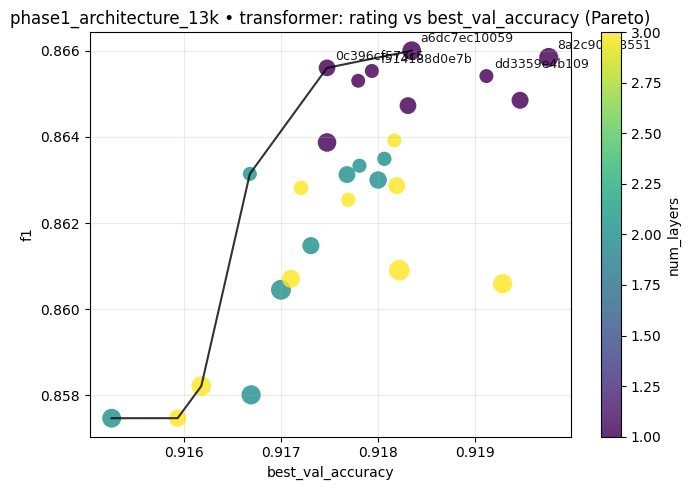

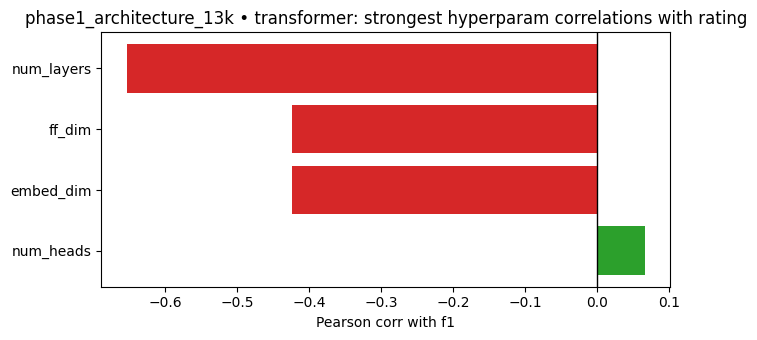

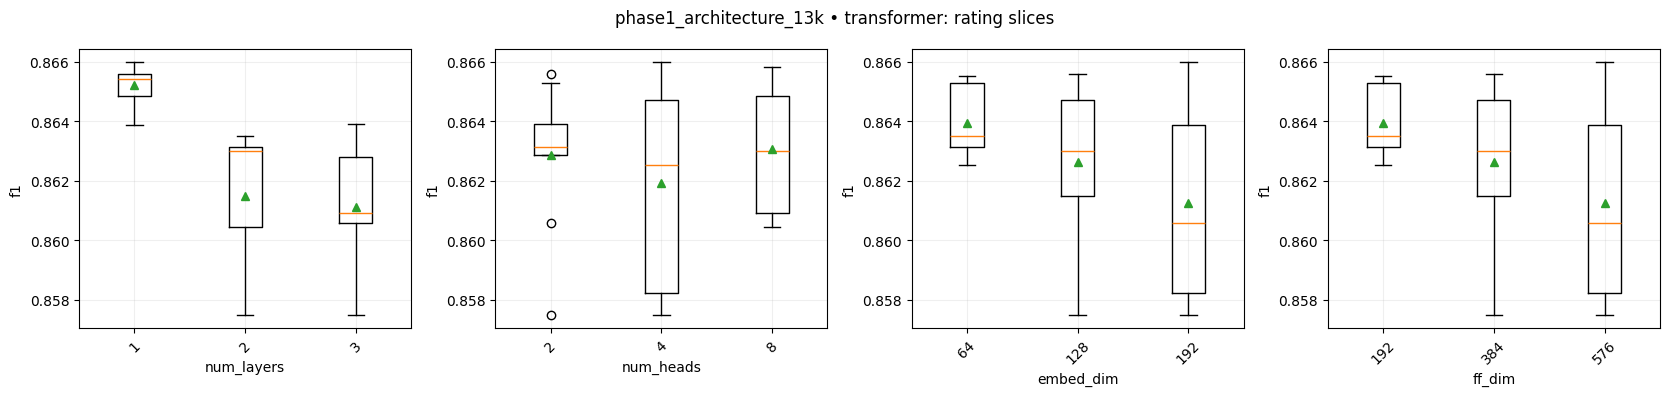

## lstm

**phase1_architecture_13k** | architecture=lstm | total_models=36 | runs_loaded=9 | unique_configs=9

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,lr,lstm_units,maxlen,patience,sentences
1,P1_lstm_arch_s13000_u160_e192_run1_seed695255021,lstm,c726729cfb01,0.925308,0.922992,0.924712,7099477,83.173129,7,32,0.2,True,192,60,0.001,160,30,3,13000
4,P1_lstm_arch_s13000_u256_e192_run1_seed1846252774,lstm,ab7e29874b4c,0.924919,0.921793,0.923262,7595797,77.815816,6,32,0.2,True,192,60,0.001,256,30,3,13000
7,P1_lstm_arch_s13000_u64_e192_run1_seed1716087199,lstm,1b6b6c3c907d,0.924776,0.922017,0.924146,6750613,88.737739,8,32,0.2,True,192,60,0.001,64,30,3,13000
2,P1_lstm_arch_s13000_u160_e64_run1_seed157682544,lstm,139f7e5ace9e,0.924613,0.922034,0.924002,2535765,100.621051,9,32,0.2,True,64,60,0.001,160,30,3,13000
5,P1_lstm_arch_s13000_u256_e64_run1_seed968182547,lstm,0ee6a9edc609,0.924367,0.923128,0.924659,2933781,111.922038,9,32,0.2,True,64,60,0.001,256,30,3,13000
0,P1_lstm_arch_s13000_u160_e128_run1_seed1953714563,lstm,79a6f3dc695e,0.924245,0.922464,0.924179,4817621,80.668911,7,32,0.2,True,128,60,0.001,160,30,3,13000
3,P1_lstm_arch_s13000_u256_e128_run1_seed600899156,lstm,6e25ce7013e2,0.924163,0.924072,0.925413,5264789,99.634856,8,32,0.2,True,128,60,0.001,256,30,3,13000
6,P1_lstm_arch_s13000_u64_e128_run1_seed795764321,lstm,e3999aac66ad,0.923243,0.921432,0.923565,4517909,94.300377,9,32,0.2,True,128,60,0.001,64,30,3,13000


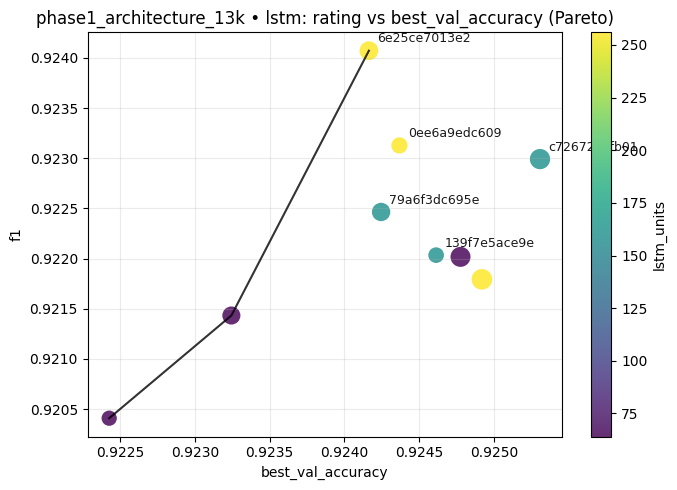

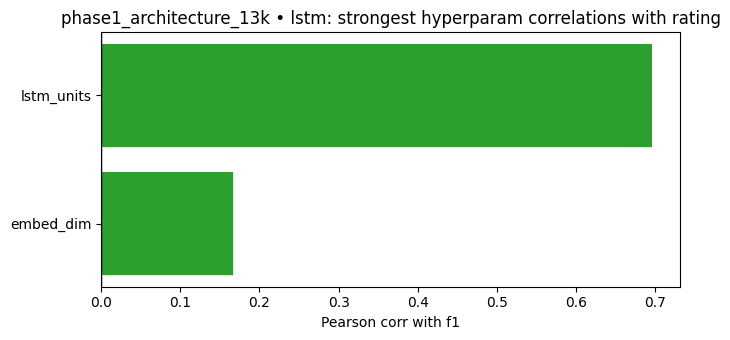

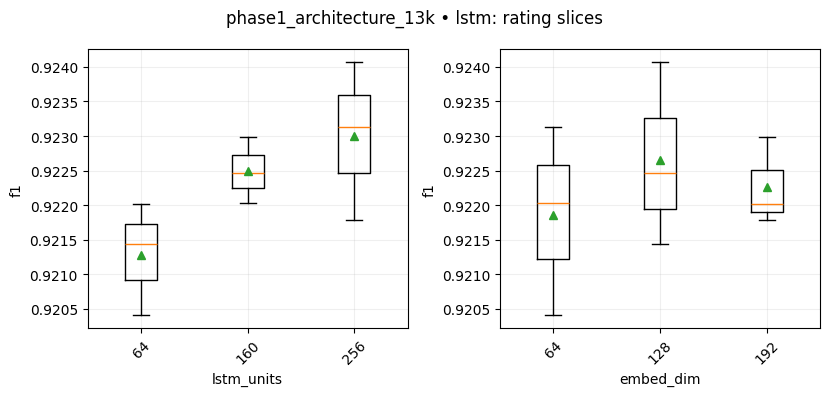

In [126]:
phase1_name = "phase1_architecture_13k"
show_phase(phase1_name, top_n=8)

## Phase 2: Optimizer + Batch Search
**What happens:** Tunes learning rate and batch size for transformer and LSTM, seeded from best Phase 1 architectures (top 3) with 2 runs each.

### **Architectures covered:**
- Transformer and LSTM.

### **Values used:**
- Transformer: lr [0.00001, 0.00002, 0.00003, 0.00005], batch_size [16, 32, 64], dropout 0.1, epochs 80, runs-count 2.
- LSTM: lr [0.001, 0.003, 0.005], batch_size [8, 16, 32], dropout 0.2, epochs 80, runs-count 2.

### **Top models & selection:**
- Displayed: top 5 per architecture, ranked separately by `best_val_accuracy` and `f1`.
- Carryover to Phase 3: top 2 per architecture via `pick_best_from` (scores averaged across runs).
- Top models used in Phase 3 are the carried-over configs from this phase.

### **Prior assumptions:**
- Lower LR improves stability; optimal LR differs by model family.
- Batch size trades off generalization vs throughput.

### **Actual results:**
- 
- 

## transformer

**phase2_optimizer_13k** | architecture=transformer | total_models=126 | runs_loaded=72 | unique_configs=36

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,ff_dim,lr,maxlen,num_heads,num_layers,patience,pick_best_parent_score,sentences
62,P2_transformer_opt_s13000_lr0p00005_b32_d0p1__from_phase1_transformer_architecture_13k_top2_run1_seed1846252774,transformer,de46cbf27042,0.921577,0.867213,0.869804,5049749,21.578660,12,32,0.1,True,128,80,384,0.00005,30,8,1,3,"[0.9194615483283997, -0.30306577682495117]",13000
59,P2_transformer_opt_s13000_lr0p00005_b16_d0p1__from_phase1_transformer_architecture_13k_top3_run2_seed1679781537,transformer,a13b4d0c2144,0.921308,0.859274,0.862464,8191253,34.086510,7,16,0.1,True,192,80,576,0.00005,30,2,3,3,"[0.9192821979522705, -0.34287095069885254]",13000
55,P2_transformer_opt_s13000_lr0p00005_b16_d0p1__from_phase1_transformer_architecture_13k_top1_run2_seed254334097,transformer,884795c9ad78,0.921218,0.865817,0.868297,8041493,28.843852,8,16,0.1,True,192,80,576,0.00005,30,8,1,3,"[0.9197567105293274, -0.3036428689956665]",13000
63,P2_transformer_opt_s13000_lr0p00005_b32_d0p1__from_phase1_transformer_architecture_13k_top2_run2_seed1311306570,transformer,de46cbf27042,0.921141,0.867757,0.870083,5049749,24.156489,12,32,0.1,True,128,80,384,0.00005,30,8,1,3,"[0.9194615483283997, -0.30306577682495117]",13000
61,P2_transformer_opt_s13000_lr0p00005_b32_d0p1__from_phase1_transformer_architecture_13k_top1_run2_seed262445022,transformer,0ee03cf4af55,0.920795,0.869145,0.871509,8041493,25.559088,11,32,0.1,True,192,80,576,0.00005,30,8,1,3,"[0.9197567105293274, -0.3036428689956665]",13000
54,P2_transformer_opt_s13000_lr0p00005_b16_d0p1__from_phase1_transformer_architecture_13k_top1_run1_seed1953714563,transformer,884795c9ad78,0.920731,0.865516,0.867409,8041493,31.023395,8,16,0.1,True,192,80,576,0.00005,30,8,1,3,"[0.9197567105293274, -0.3036428689956665]",13000
42,P2_transformer_opt_s13000_lr0p00003_b32_d0p1__from_phase1_transformer_architecture_13k_top1_run1_seed1022542093,transformer,8e153b8bd63a,0.920488,0.869237,0.871840,8041493,31.036297,15,32,0.1,True,192,80,576,0.00003,30,8,1,3,"[0.9197567105293274, -0.3036428689956665]",13000
36,P2_transformer_opt_s13000_lr0p00003_b16_d0p1__from_phase1_transformer_architecture_13k_top1_run1_seed1061903684,transformer,067e06df17d1,0.920244,0.865650,0.868057,8041493,39.699499,11,16,0.1,True,192,80,576,0.00003,30,8,1,3,"[0.9197567105293274, -0.3036428689956665]",13000


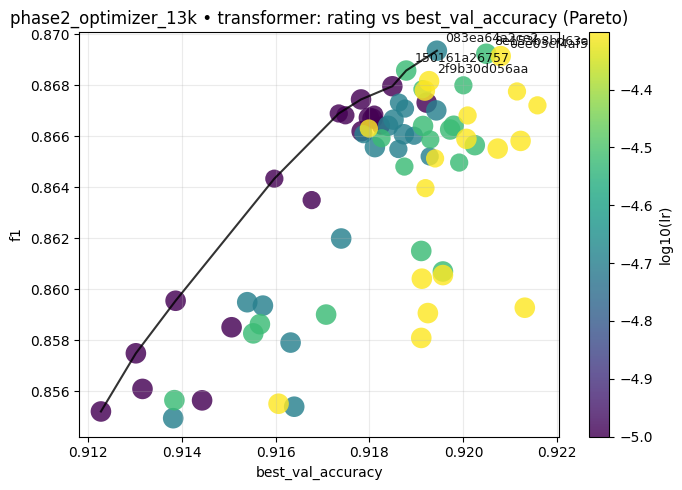

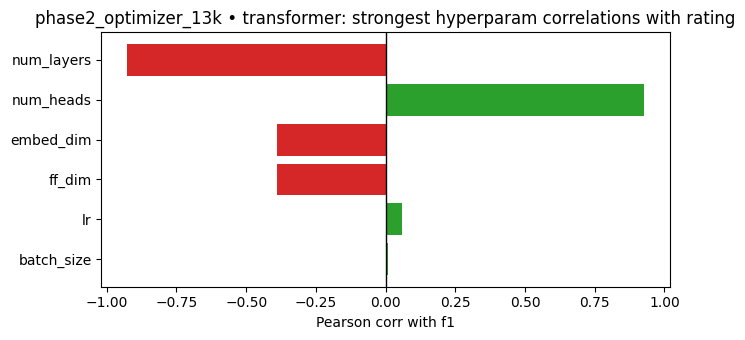

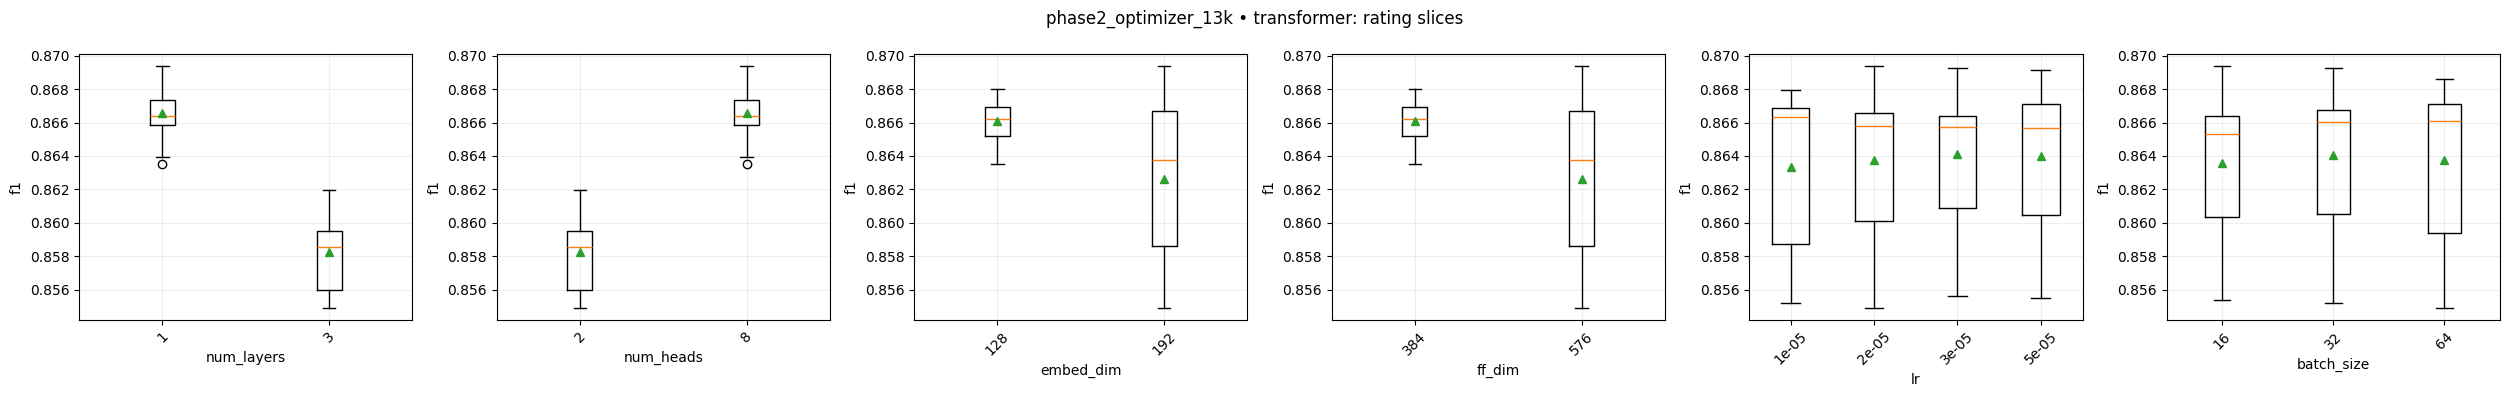

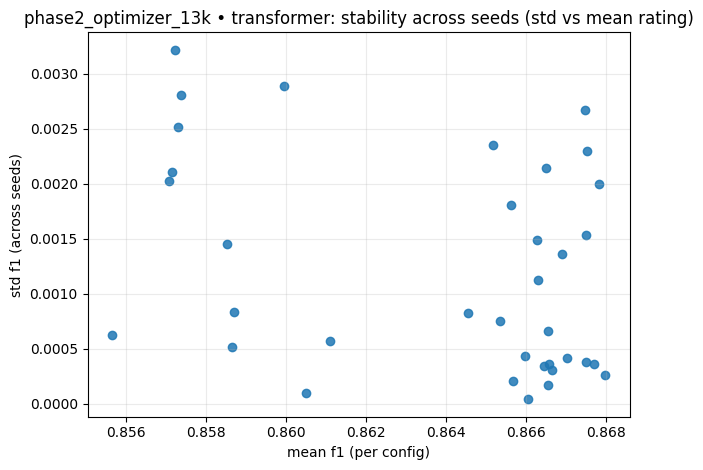

## lstm

**phase2_optimizer_13k** | architecture=lstm | total_models=126 | runs_loaded=54 | unique_configs=27

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,lr,lstm_units,maxlen,patience,pick_best_parent_score,sentences
36,P2_lstm_opt_s13000_lr0p005_b16_d0p2__from_phase1_lstm_architecture_13k_top1_run1_seed417765555,lstm,c529c8006cb8,0.929905,0.928222,0.929470,7099477,115.578431,5,16,0.2,True,192,80,0.005,160,30,3,"[0.9253076314926147, -0.25746577978134155]",13000
43,P2_lstm_opt_s13000_lr0p005_b32_d0p2__from_phase1_lstm_architecture_13k_top1_run2_seed986830554,lstm,7ca55c6fbfa5,0.929374,0.928154,0.929331,7099477,59.736301,5,32,0.2,True,192,80,0.005,160,30,3,"[0.9253076314926147, -0.25746577978134155]",13000
31,P2_lstm_opt_s13000_lr0p003_b8_d0p2__from_phase1_lstm_architecture_13k_top1_run2_seed392038730,lstm,003c92eca463,0.929190,0.929281,0.930689,7099477,224.624494,5,8,0.2,True,192,80,0.003,160,30,3,"[0.9253076314926147, -0.25746577978134155]",13000
19,P2_lstm_opt_s13000_lr0p003_b16_d0p2__from_phase1_lstm_architecture_13k_top1_run2_seed2091053660,lstm,62a5f4f51735,0.929027,0.925992,0.927405,7099477,117.784200,5,16,0.2,True,192,80,0.003,160,30,3,"[0.9253076314926147, -0.25746577978134155]",13000
21,P2_lstm_opt_s13000_lr0p003_b16_d0p2__from_phase1_lstm_architecture_13k_top2_run2_seed1648897541,lstm,6da82aeb3863,0.928904,0.925811,0.927468,7595797,126.127526,5,16,0.2,True,192,80,0.003,256,30,3,"[0.924919068813324, -0.25571873784065247]",13000
48,P2_lstm_opt_s13000_lr0p005_b8_d0p2__from_phase1_lstm_architecture_13k_top1_run1_seed2102494121,lstm,1a3aa018490f,0.928720,0.921761,0.923301,7099477,184.294511,4,8,0.2,True,192,80,0.005,160,30,3,"[0.9253076314926147, -0.25746577978134155]",13000
33,P2_lstm_opt_s13000_lr0p003_b8_d0p2__from_phase1_lstm_architecture_13k_top2_run2_seed1142158966,lstm,eaafff268613,0.928373,0.928572,0.929801,7595797,251.232484,5,8,0.2,True,192,80,0.003,256,30,3,"[0.924919068813324, -0.25571873784065247]",13000
37,P2_lstm_opt_s13000_lr0p005_b16_d0p2__from_phase1_lstm_architecture_13k_top1_run2_seed921193755,lstm,c529c8006cb8,0.928209,0.927420,0.928635,7099477,116.644397,5,16,0.2,True,192,80,0.005,160,30,3,"[0.9253076314926147, -0.25746577978134155]",13000


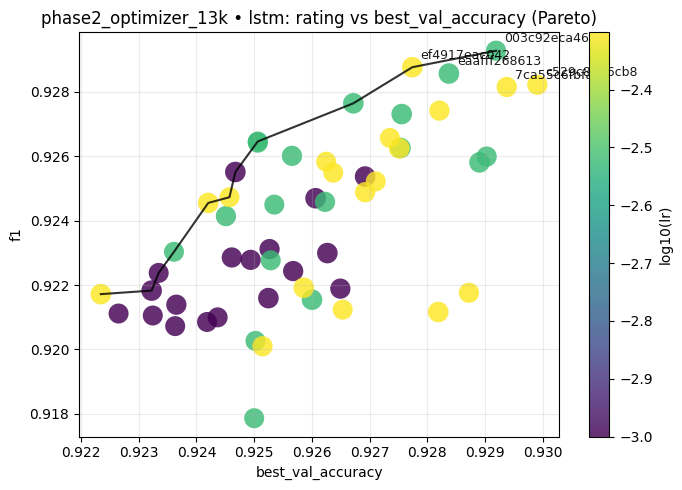

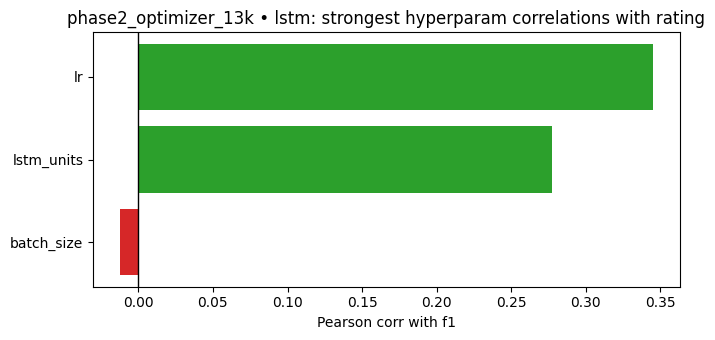

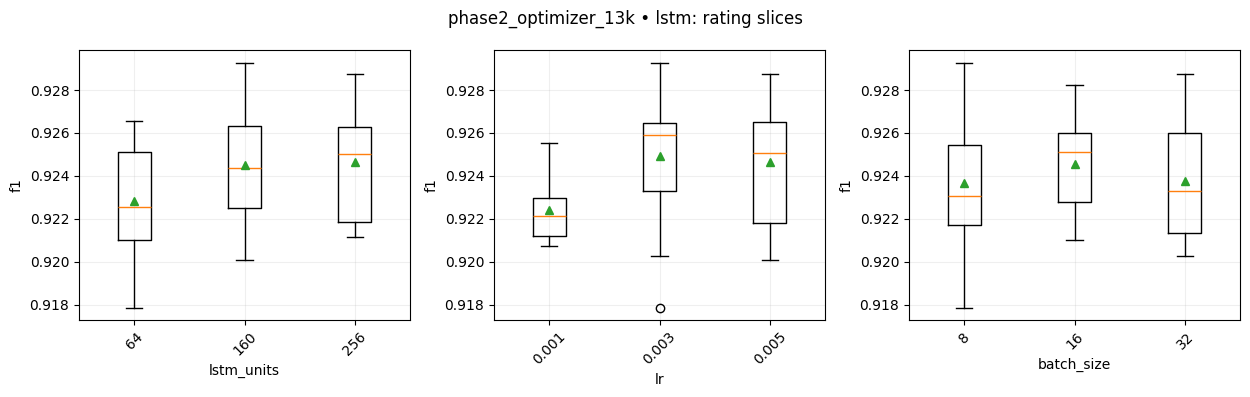

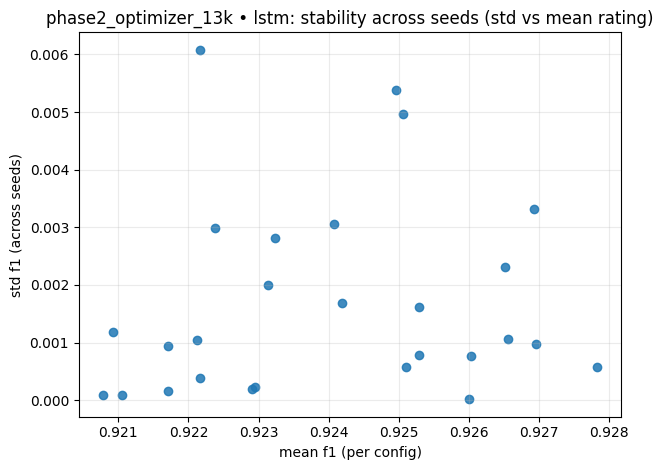

In [127]:
phase2_name = "phase2_optimizer_13k"
show_phase(phase2_name, top_n=8)

## Phase 3: Regularization Sweep
**What happens:** Sweeps dropout for both families, seeded from best Phase 2 configs (top 2) with 3 runs each.

### **Architectures covered:**
- Transformer and LSTM.

### **Values used:**
- Transformer: dropout [0.0, 0.1, 0.2, 0.3], epochs 90, runs-count 3.
- LSTM: dropout [0.1, 0.2, 0.3], epochs 90, runs-count 3.

### **Top models & selection:**
- Displayed: top 5 per architecture, ranked separately by `best_val_accuracy` and `f1`.
- Carryover to Phase 4: top 2 per architecture via `pick_best_from` (scores averaged across runs).
- Top models used in Phase 4 are the carried-over configs from this phase.

### **Prior assumptions:**
- Moderate dropout improves generalization, too much harms accuracy.
- Optimal dropout differs between transformer and LSTM.

### **Actual results:**
- 
- 

## transformer

**phase3_regularization_13k** | architecture=transformer | total_models=42 | runs_loaded=24 | unique_configs=8

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,ff_dim,lr,maxlen,num_heads,num_layers,patience,pick_best_parent_score,sentences
16,P3_transformer_reg_s13000_d0p2__from_phase2_transformer_optimizer_13k_top2_run2_seed677431482,transformer,542af401be84,0.923128,0.870111,0.872205,8041493,34.914854,10,16,0.2,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
22,P3_transformer_reg_s13000_d0p3__from_phase2_transformer_optimizer_13k_top2_run2_seed1837591841,transformer,73c9933d9eab,0.922936,0.869466,0.872041,8041493,36.023415,10,16,0.3,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
4,P3_transformer_reg_s13000_d0__from_phase2_transformer_optimizer_13k_top2_run2_seed1116735497,transformer,8c1eac37b6b5,0.922846,0.865902,0.868782,8041493,33.472505,9,16,0.0,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
15,P3_transformer_reg_s13000_d0p2__from_phase2_transformer_optimizer_13k_top2_run1_seed1177159969,transformer,542af401be84,0.922487,0.864827,0.867135,8041493,33.469768,9,16,0.2,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
11,P3_transformer_reg_s13000_d0p1__from_phase2_transformer_optimizer_13k_top2_run3_seed858981437,transformer,85ad5042e89d,0.922436,0.865322,0.868278,8041493,32.974017,9,16,0.1,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
10,P3_transformer_reg_s13000_d0p1__from_phase2_transformer_optimizer_13k_top2_run2_seed164031801,transformer,85ad5042e89d,0.922385,0.870568,0.872267,8041493,35.967096,10,16,0.1,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
5,P3_transformer_reg_s13000_d0__from_phase2_transformer_optimizer_13k_top2_run3_seed1163876029,transformer,8c1eac37b6b5,0.922346,0.861943,0.867073,8041493,33.778017,9,16,0.0,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000
21,P3_transformer_reg_s13000_d0p3__from_phase2_transformer_optimizer_13k_top2_run1_seed1068451633,transformer,73c9933d9eab,0.922128,0.868181,0.870265,8041493,36.892357,10,16,0.3,True,192,90,576,0.00005,30,8,1,4,"[0.920974612236023, -0.30395781993865967]",13000


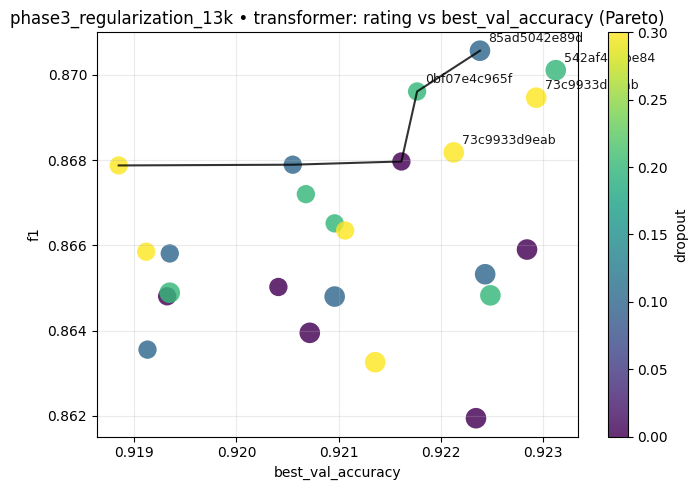

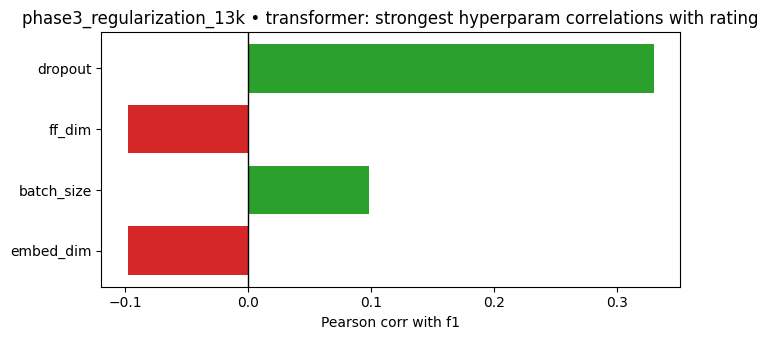

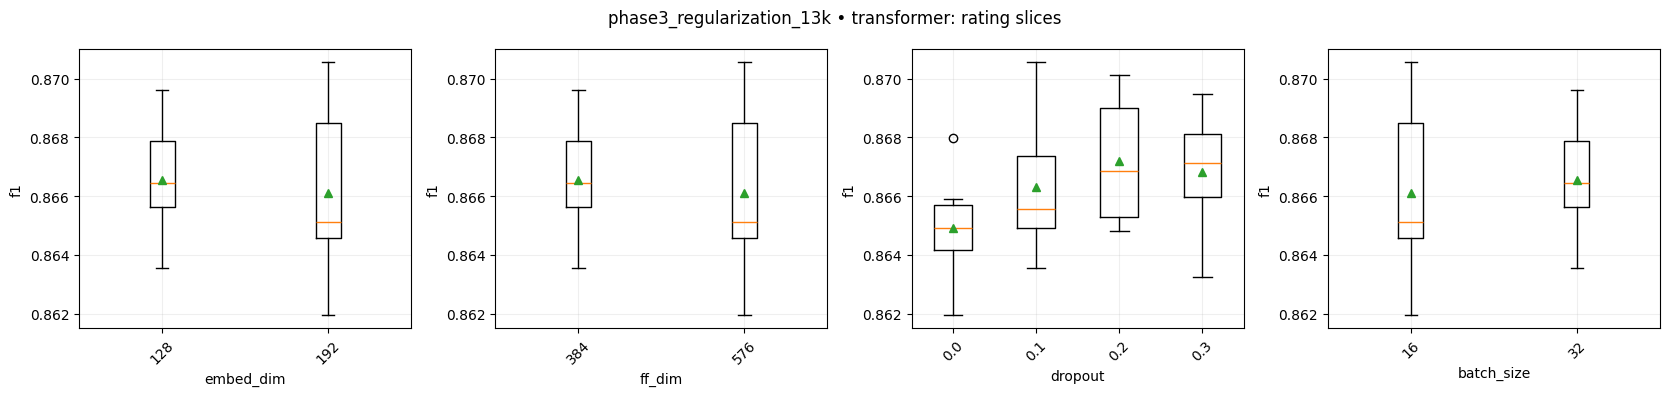

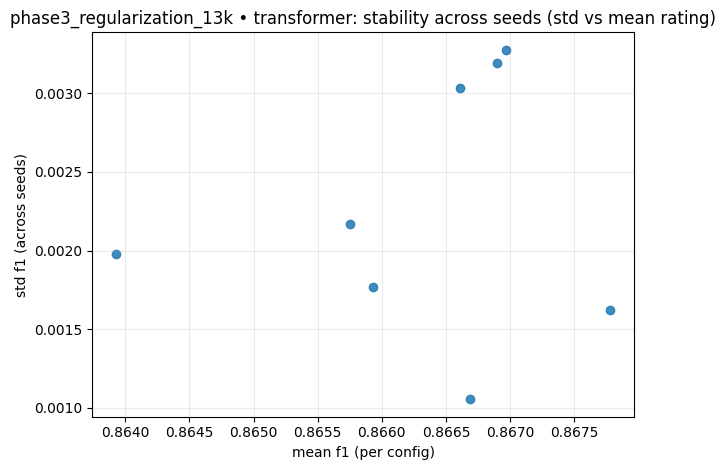

## lstm

**phase3_regularization_13k** | architecture=lstm | total_models=42 | runs_loaded=18 | unique_configs=6

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,lr,lstm_units,maxlen,patience,pick_best_parent_score,sentences
6,P3_lstm_reg_s13000_d0p2__from_phase2_lstm_optimizer_13k_top1_run1_seed1325301227,lstm,373652eb423e,0.930437,0.928903,0.930089,7099477,138.991459,6,16,0.2,True,192,90,0.005,160,30,4,"[0.9290572106838226, -0.2413068786263466]",13000
8,P3_lstm_reg_s13000_d0p2__from_phase2_lstm_optimizer_13k_top1_run3_seed1911557998,lstm,373652eb423e,0.929415,0.928034,0.929350,7099477,138.396756,6,16,0.2,True,192,90,0.005,160,30,4,"[0.9290572106838226, -0.2413068786263466]",13000
0,P3_lstm_reg_s13000_d0p1__from_phase2_lstm_optimizer_13k_top1_run1_seed522950408,lstm,0a2bf044e6eb,0.929272,0.925012,0.926863,7099477,116.397693,5,16,0.1,True,192,90,0.005,160,30,4,"[0.9290572106838226, -0.2413068786263466]",13000
15,P3_lstm_reg_s13000_d0p3__from_phase2_lstm_optimizer_13k_top2_run1_seed2074295653,lstm,3a3778b51550,0.928904,0.926056,0.927583,7595797,152.878042,6,16,0.3,True,192,90,0.003,256,30,4,"[0.9282295405864716, -0.24251984804868698]",13000
12,P3_lstm_reg_s13000_d0p3__from_phase2_lstm_optimizer_13k_top1_run1_seed194003353,lstm,45f585a87343,0.928863,0.927972,0.928865,7099477,136.287396,6,16,0.3,True,192,90,0.005,160,30,4,"[0.9290572106838226, -0.2413068786263466]",13000
5,P3_lstm_reg_s13000_d0p1__from_phase2_lstm_optimizer_13k_top2_run3_seed117086499,lstm,2e992ad0635f,0.928843,0.927320,0.928855,7595797,149.701448,6,16,0.1,True,192,90,0.003,256,30,4,"[0.9282295405864716, -0.24251984804868698]",13000
1,P3_lstm_reg_s13000_d0p1__from_phase2_lstm_optimizer_13k_top1_run2_seed1800644320,lstm,0a2bf044e6eb,0.928557,0.922856,0.924439,7099477,113.532261,5,16,0.1,True,192,90,0.005,160,30,4,"[0.9290572106838226, -0.2413068786263466]",13000
9,P3_lstm_reg_s13000_d0p2__from_phase2_lstm_optimizer_13k_top2_run1_seed1962033342,lstm,d2648286f353,0.928373,0.926725,0.927948,7595797,152.884987,6,16,0.2,True,192,90,0.003,256,30,4,"[0.9282295405864716, -0.24251984804868698]",13000


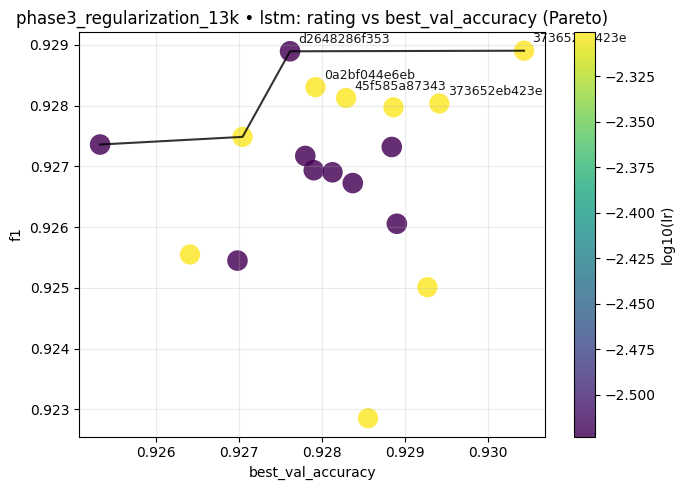

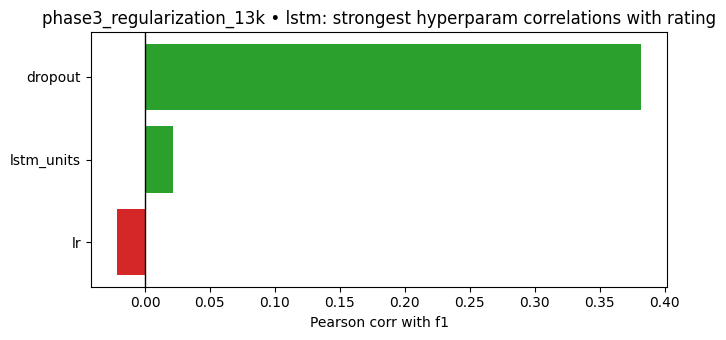

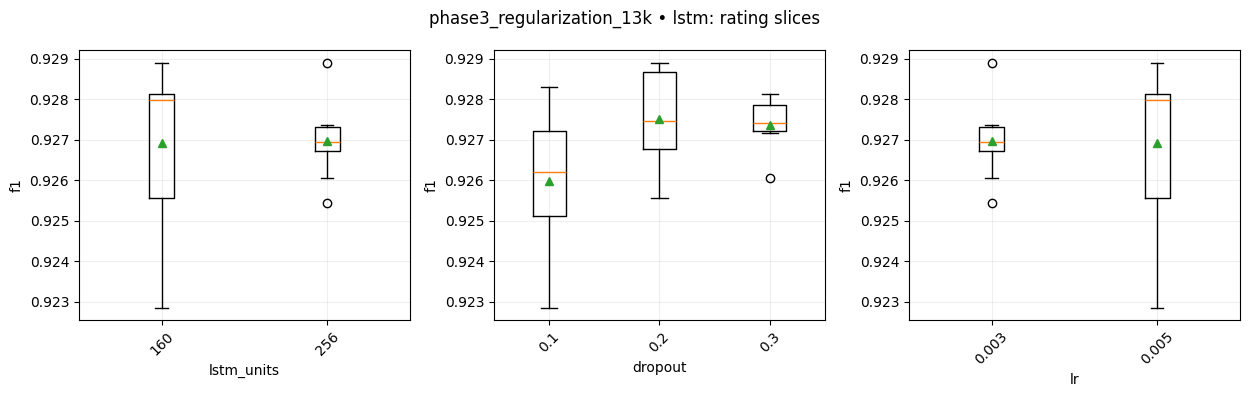

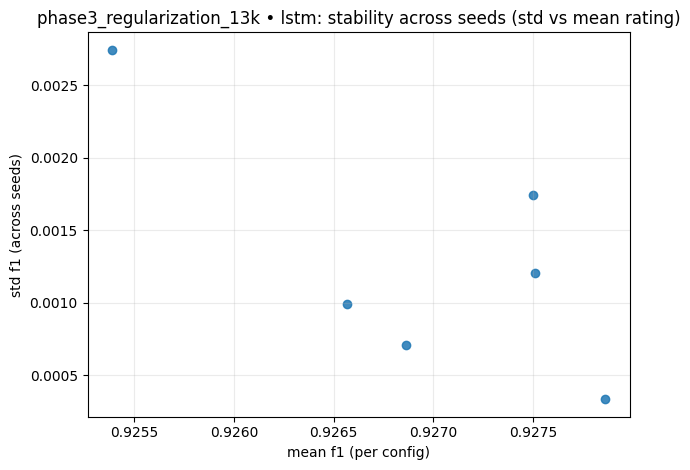

In [128]:
phase3_name = "phase3_regularization_13k"
show_phase(phase3_name, top_n=8)

## Phase 4: Robustness Runs
**What happens:** Runs multiple seeds on the best Phase 3 configs (top 2) to check stability, 5 runs each.

### **Architectures covered:**
- Transformer and LSTM.

### **Values used:**
- Transformer: epochs 100, runs-count 5 (top 2 configs from Phase 3).
- LSTM: epochs 100, runs-count 5 (top 2 configs from Phase 3).

### **Top models & selection:**
- Displayed: top 5 per architecture, ranked separately by `best_val_accuracy` and `f1`.
- No further carryover; this phase measures stability across seeds.

### **Prior assumptions:**
- Best configs should remain stable across seeds.
- Variance highlights model family robustness differences.

### **Actual results:**
- 
- 

## transformer

**phase4_robustness_13k** | architecture=transformer | total_models=20 | runs_loaded=10 | unique_configs=2

**Top-2 config stability (mean/std across seeds)**

,config_id,n_runs,f1_mean,f1_std,best_val_accuracy_mean,best_val_accuracy_std
0,2c7a185b06d9,5,0.867751,0.002161,0.921913,0.000934
1,ce3cefe164f7,5,0.864789,0.001845,0.921541,0.000981


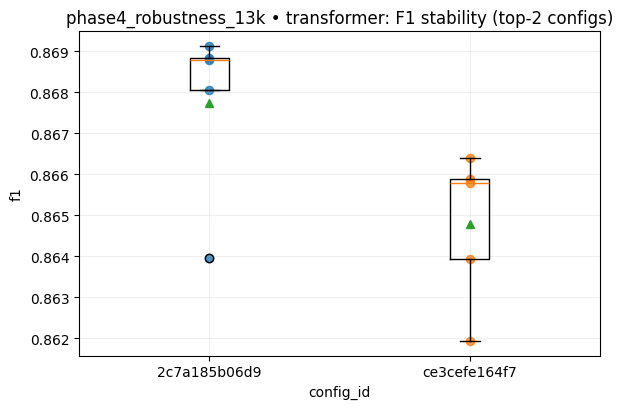

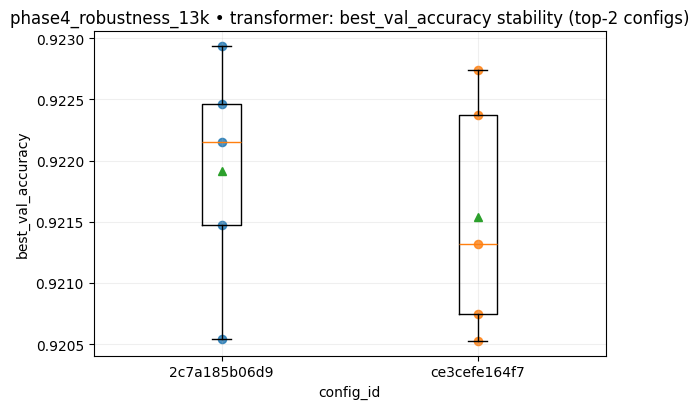

## lstm

**phase4_robustness_13k** | architecture=lstm | total_models=20 | runs_loaded=10 | unique_configs=2

**Top-2 config stability (mean/std across seeds)**

,config_id,n_runs,f1_mean,f1_std,best_val_accuracy_mean,best_val_accuracy_std
0,30c9e13dfb62,5,0.924417,0.003290,0.92749,0.001112
1,eb4aa38f7ff8,5,0.924363,0.002604,0.92722,0.001467


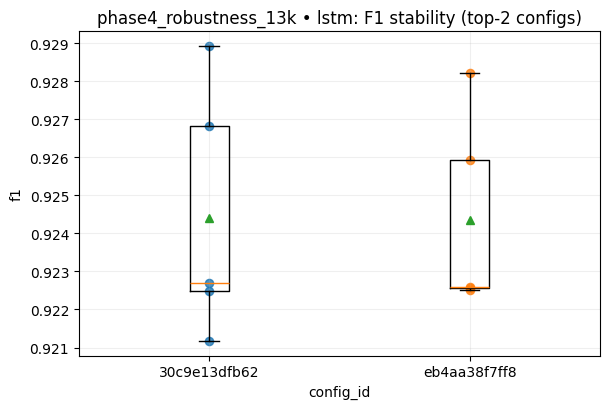

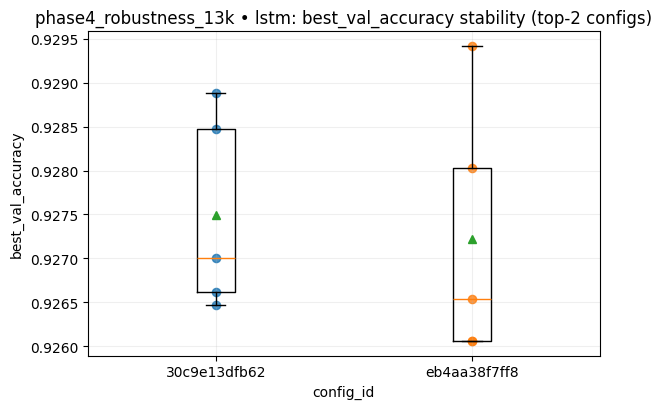

In [129]:
phase4_name = "phase4_robustness_13k"
top_n = 8

def _top2_stability_table(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "config_id" not in df.columns:
        return pd.DataFrame()

    agg_cols = [c for c in ("f1", "best_val_accuracy") if c in df.columns]
    if not agg_cols:
        return pd.DataFrame()

    grouped = (
        df.dropna(subset=agg_cols)
        .groupby("config_id", dropna=False)[agg_cols]
        .agg(["count", "mean", "std"])
    )
    # flatten columns -> metric_stat
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    grouped = grouped.reset_index()

    # Choose top 2 configs by mean best_val_accuracy (fallback: mean f1).
    if "best_val_accuracy_mean" in grouped.columns:
        sort_cols = ["best_val_accuracy_mean", "best_val_accuracy_std"]
    else:
        sort_cols = ["f1_mean", "f1_std"]

    # Lower std is better; mean descending.
    asc = [False, True]
    grouped = grouped.sort_values(sort_cols, ascending=asc, kind="mergesort")

    # Compute n_runs consistently (use the first available metric count).
    count_col = None
    for c in ("best_val_accuracy_count", "f1_count"):
        if c in grouped.columns:
            count_col = c
            break
    if count_col is not None:
        grouped = grouped.rename(columns={count_col: "n_runs"})
        for c in ("best_val_accuracy_count", "f1_count"):
            if c in grouped.columns and c != "n_runs":
                grouped = grouped.drop(columns=[c])

    # Keep only the essentials and the two stability metrics.
    keep = ["config_id"]
    if "n_runs" in grouped.columns:
        keep.append("n_runs")
    for c in (
        "f1_mean",
        "f1_std",
        "best_val_accuracy_mean",
        "best_val_accuracy_std",
    ):
        if c in grouped.columns:
            keep.append(c)

    out = grouped[keep].head(2).copy()
    # prettier numeric formatting for display
    for c in out.columns:
        if c.endswith("_mean") or c.endswith("_std"):
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def _boxplot_two_configs(df: pd.DataFrame, *, config_ids: list[str], metric: str, title: str) -> None:
    if df.empty or metric not in df.columns or "config_id" not in df.columns:
        return
    sub = df[df["config_id"].isin(config_ids)][["config_id", metric]].dropna()
    if sub.empty:
        return

    order = [cid for cid in config_ids if cid in set(sub["config_id"].unique())]
    data = [sub.loc[sub["config_id"] == cid, metric].astype(float).values for cid in order]
    if not data:
        return

    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    try:
        ax.boxplot(data, tick_labels=order, showmeans=True)
    except TypeError:
        ax.boxplot(data, labels=order, showmeans=True)
    # overlay points
    for i, cid in enumerate(order, start=1):
        ys = sub.loc[sub["config_id"] == cid, metric].astype(float).values
        xs = [i] * len(ys)
        ax.scatter(xs, ys, s=35, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("config_id")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


for model_type in ("transformer", "lstm"):
    try:
        summary, models = load_phase_results(phase4_name)
    except FileNotFoundError as e:
        print(str(e))
        break

    arch_models = _filter_by_arch(models, model_type)
    if not arch_models:
        print(f"Phase: {phase4_name} | architecture={model_type} | no runs found")
        print("\n")
        continue

    df = models_frame(arch_models)
    total = summary.get("total_models")

    display(Markdown(f"## {model_type}"))
    display(
        Markdown(
            f"**{phase4_name}** | architecture={model_type} | total_models={total} | runs_loaded={len(arch_models)} | unique_configs={df['config_id'].nunique()}"
        )
    )

    # Phase 4 focus: robustness across seeds (stability), specifically the top-2 configs (5 runs each).
    stab2 = _top2_stability_table(df)
    if stab2.empty:
        print("Not enough data to compute top-2 stability.")
        print("\n")
        continue

    display(Markdown("**Top-2 config stability (mean/std across seeds)**"))
    display(stab2)

    top2_ids = stab2["config_id"].astype(str).tolist()
    # Run-level values for the same top-2 configs
    run_cols = [c for c in ("config_id", "run_seed", "name", "f1", "best_val_accuracy") if c in df.columns]
    runs_view = df[df["config_id"].isin(top2_ids)][run_cols].copy()
    if "run_seed" in runs_view.columns:
        runs_view = runs_view.sort_values(["config_id", "run_seed"], kind="mergesort")
    else:
        runs_view = runs_view.sort_values(["config_id"], kind="mergesort")

    # Stability plots (boxplots) for the top-2 configs
    _boxplot_two_configs(
        df,
        config_ids=top2_ids,
        metric="f1",
        title=f"{phase4_name} • {model_type}: F1 stability (top-2 configs)",
    )
    _boxplot_two_configs(
        df,
        config_ids=top2_ids,
        metric="best_val_accuracy",
        title=f"{phase4_name} • {model_type}: best_val_accuracy stability (top-2 configs)",
    )

    print("\n")

## Phase 5: Scalability

**What happens:** Stress-tests the best-performing configs under more demanding settings (e.g., longer sequences and/or larger batches) and compares the *performance vs cost* trade-offs.

This notebook will still rank by **test F1**, but in this phase you’ll usually want to also look at any recorded runtime/throughput signals in the raw result JSONs (if present).

## transformer

**phase5_scalability** | architecture=transformer | total_models=18 | runs_loaded=10 | unique_configs=10

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,ff_dim,lr,maxlen,num_heads,num_layers,patience,pick_best_parent_score,sentences
8,P5_transformer_scalability_s45000_final__from_phase3_transformer_regularization_13k_top1_run1_seed522950408,transformer,8a87956c6a26,0.953115,0.914542,0.916157,10905206,92.597970,8,16,0.3,True,192,100,576,0.00005,30,8,1,4,"[0.9221410552660624, -0.3026312291622162]",45000
9,P5_transformer_scalability_s45000_final__from_phase3_transformer_regularization_13k_top2_run1_seed2101001059,transformer,f210addaa553,0.951570,0.914280,0.916138,10905206,87.697746,8,16,0.0,True,192,100,576,0.00005,30,8,1,4,"[0.9219700892766317, -0.30313973625500995]",45000
6,P5_transformer_scalability_s40000_final__from_phase3_transformer_regularization_13k_top1_run1_seed143632255,transformer,cf16998f882f,0.949762,0.910003,0.912206,10617968,80.017483,8,16,0.3,True,192,100,576,0.00005,30,8,1,4,"[0.9221410552660624, -0.3026312291622162]",40000
7,P5_transformer_scalability_s40000_final__from_phase3_transformer_regularization_13k_top2_run1_seed1068451633,transformer,59cd816fa5fa,0.949112,0.910077,0.911635,10617968,76.849190,8,16,0.0,True,192,100,576,0.00005,30,8,1,4,"[0.9219700892766317, -0.30313973625500995]",40000
2,P5_transformer_scalability_s25000_final__from_phase3_transformer_regularization_13k_top1_run1_seed583848003,transformer,44bf7817b682,0.936753,0.892010,0.893934,9468823,56.195454,8,16,0.3,True,192,100,576,0.00005,30,8,1,4,"[0.9221410552660624, -0.3026312291622162]",25000
3,P5_transformer_scalability_s25000_final__from_phase3_transformer_regularization_13k_top2_run1_seed1907541172,transformer,ed7161d268cc,0.935426,0.891658,0.893842,9468823,52.004072,8,16,0.0,True,192,100,576,0.00005,30,8,1,4,"[0.9219700892766317, -0.30313973625500995]",25000
4,P5_transformer_scalability_s30000_final__from_phase3_transformer_regularization_13k_top1_run1_seed755584081,transformer,700d4d6bbd21,0.933006,0.898828,0.900736,10004124,61.803647,8,16,0.3,True,192,100,576,0.00005,30,8,1,4,"[0.9221410552660624, -0.3026312291622162]",30000
5,P5_transformer_scalability_s30000_final__from_phase3_transformer_regularization_13k_top2_run1_seed1177159969,transformer,5f651d6ff1a2,0.932044,0.899248,0.901221,10004124,59.679649,8,16,0.0,True,192,100,576,0.00005,30,8,1,4,"[0.9219700892766317, -0.30313973625500995]",30000


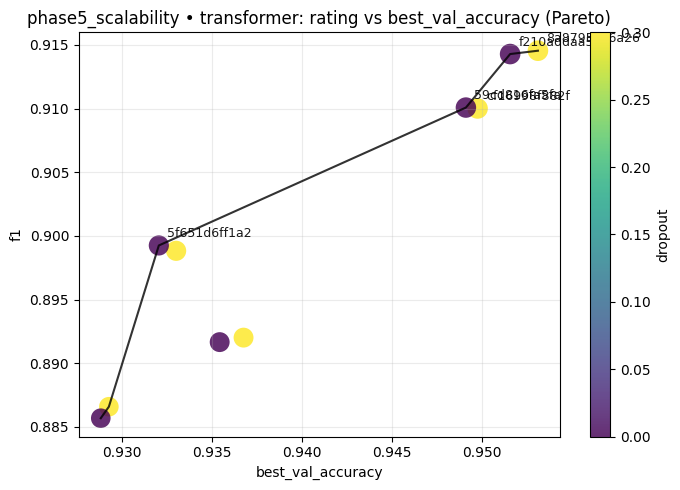

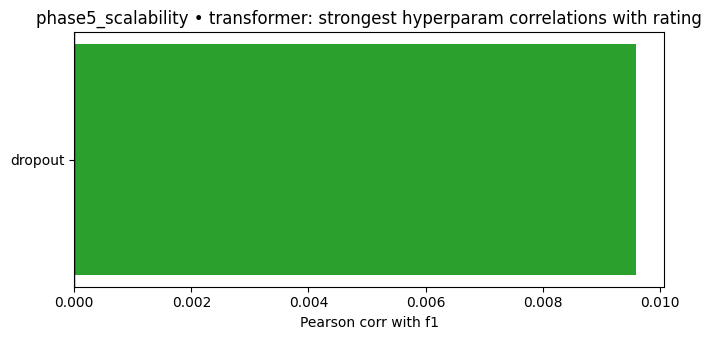

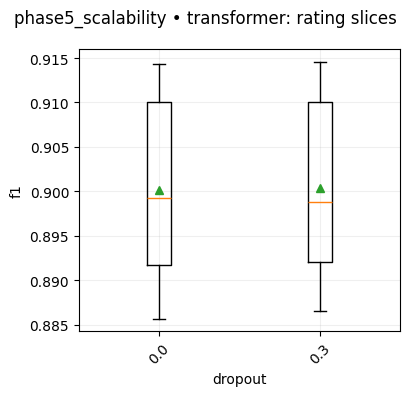

## lstm

**phase5_scalability** | architecture=lstm | total_models=18 | runs_loaded=8 | unique_configs=8

Leaderboard (sorted by best_val_accuracy):


,name,model_type,config_id,best_val_accuracy,f1,token_accuracy,num_params,train_time_sec,epochs_ran,batch_size,dropout,early_stopping,embed_dim,epochs,lr,lstm_units,maxlen,patience,pick_best_parent_score,sentences
2,P5_lstm_scalability_s25000_final__from_phase3_lstm_regularization_13k_top1_run1_seed194003353,lstm,94c146d12002,0.946124,0.943272,0.944319,8527063,219.164167,5,16,0.2,True,192,100,0.005,160,30,4,"[0.9287542104721069, -0.24401691059271494]",25000
3,P5_lstm_scalability_s25000_final__from_phase3_lstm_regularization_13k_top2_run1_seed2074295653,lstm,f5279699940e,0.945100,0.943149,0.943959,8527063,219.409945,5,16,0.1,True,192,100,0.005,160,30,4,"[0.9285839398701986, -0.24045105775197348]",25000
1,P5_lstm_scalability_s20000_final__from_phase3_lstm_regularization_13k_top2_run1_seed1962033342,lstm,61efb639c21d,0.944322,0.936095,0.936988,7970902,173.525565,5,16,0.1,True,192,100,0.005,160,30,4,"[0.9285839398701986, -0.24045105775197348]",20000
5,P5_lstm_scalability_s30000_final__from_phase3_lstm_regularization_13k_top2_run1_seed1247166526,lstm,121694b36738,0.943588,0.948909,0.949533,9063004,262.710485,5,16,0.1,True,192,100,0.005,160,30,4,"[0.9285839398701986, -0.24045105775197348]",30000
0,P5_lstm_scalability_s20000_final__from_phase3_lstm_regularization_13k_top1_run1_seed1325301227,lstm,4cc8cea0696a,0.943311,0.935517,0.936786,7970902,176.251280,5,16,0.2,True,192,100,0.005,160,30,4,"[0.9287542104721069, -0.24401691059271494]",20000
7,P5_lstm_scalability_s40000_final__from_phase3_lstm_regularization_13k_top2_run1_seed661009984,lstm,1fa92651df57,0.942822,0.955566,0.956057,9679408,352.386898,5,16,0.1,True,192,100,0.005,160,30,4,"[0.9285839398701986, -0.24045105775197348]",40000
6,P5_lstm_scalability_s40000_final__from_phase3_lstm_regularization_13k_top1_run1_seed481434643,lstm,1e3f79fba26e,0.942456,0.955076,0.955644,9679408,351.777778,5,16,0.2,True,192,100,0.005,160,30,4,"[0.9287542104721069, -0.24401691059271494]",40000
4,P5_lstm_scalability_s30000_final__from_phase3_lstm_regularization_13k_top1_run1_seed91409179,lstm,413db597de1c,0.941716,0.947607,0.947973,9063004,263.060311,5,16,0.2,True,192,100,0.005,160,30,4,"[0.9287542104721069, -0.24401691059271494]",30000


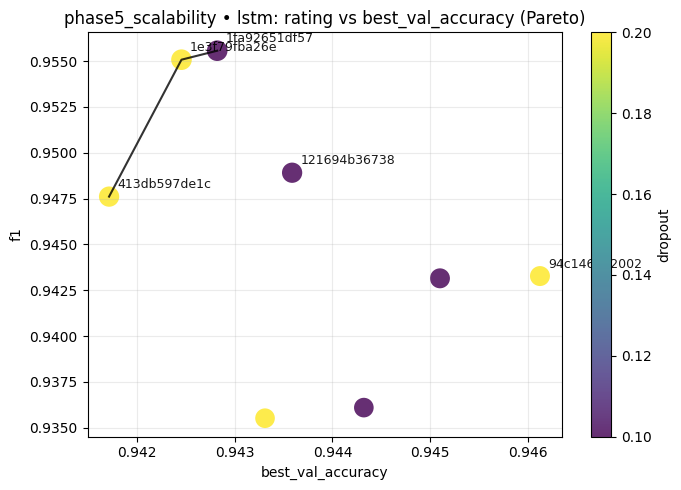

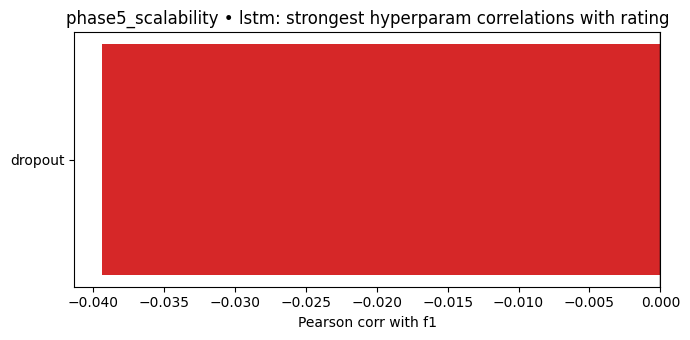

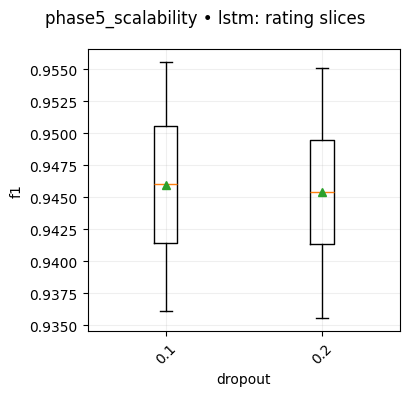

In [130]:
phase5_name = "phase5_scalability"
show_phase(phase5_name, top_n=8)

## Conclusion: Which architecture to choose?

This section aggregates the phase results and recommends **one** architecture to carry forward.

**Decision rule (simple + practical):**
- Use the **latest phase that has results for both architectures**.
- Rank configs by **mean test F1 across seeds** (when multiple runs exist); break ties by lower F1 std.
- If some later phases are missing/empty, the conclusion will explicitly say so.

In [131]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import pandas as pd
from IPython.display import Markdown, display


@dataclass(frozen=True)
class ArchPick:
    phase: str
    arch: str
    config_id: str
    mean_rating: float
    std_rating: float
    best_rating: float
    n_runs: int


def _phase_sort_key(phase_name: str) -> tuple[int, str]:
    import re

    m = re.match(r"phase(\d+)_", phase_name)
    return (int(m.group(1)) if m else 999, phase_name)


def _rating_label_local(rating_spec: str) -> str:
    rating_spec = (rating_spec or "").strip()
    return rating_spec if rating_spec else "f1"


def _ensure_rating_local(df: pd.DataFrame, rating_spec: str) -> pd.DataFrame:
    """Ensure `_rating` exists; works even if the rating-config cell wasn't executed."""
    if df.empty:
        return df

    rating_spec = (rating_spec or "").strip() or "f1"

    # Prefer the notebook-level helper if present
    if "_ensure_rating_column" in globals():
        try:
            return globals()["_ensure_rating_column"](df, rating_spec)
        except Exception:
            pass

    out = df.copy()
    if rating_spec in out.columns:
        out["_rating"] = pd.to_numeric(out[rating_spec], errors="coerce")
        return out

    local = {c: pd.to_numeric(out[c], errors="coerce") for c in out.columns}
    try:
        rating = pd.eval(rating_spec, local_dict=local, engine="python")
    except Exception as e:
        raise ValueError(
            f"Invalid rating expression: {rating_spec!r}. "
            f"Use a column name like 'f1' or an expression over columns like '0.7*f1 + 0.3*best_val_accuracy'."
        ) from e

    out["_rating"] = pd.to_numeric(rating, errors="coerce")
    return out


def _best_config_by_mean_rating(df: pd.DataFrame) -> Optional[pd.Series]:
    if df.empty or "_rating" not in df.columns:
        return None

    grouped = (
        df.groupby("config_id", dropna=False)["_rating"]
        .agg(mean_rating="mean", std_rating="std", best_rating="max", n_runs="size")
        .reset_index()
    )
    grouped["std_rating"] = grouped["std_rating"].fillna(0.0)

    grouped = grouped.sort_values(
        by=["mean_rating", "std_rating", "best_rating", "n_runs"],
        ascending=[False, True, False, False],
        kind="mergesort",
    )
    return grouped.iloc[0]


def pick_architecture_across_phases(
    phase_names: list[str],
    *,
    rating_spec: str,
    arch_candidates: tuple[str, ...] = ("lstm", "transformer"),
) -> tuple[pd.DataFrame, Optional[ArchPick]]:
    """Return (summary_table, final_pick) using `rating_spec`.

    final_pick uses the latest phase where we have results for ALL `arch_candidates`.
    """

    rows: list[dict] = []
    bests_by_phase: dict[str, dict[str, ArchPick]] = {}

    for phase in sorted(phase_names, key=_phase_sort_key):
        try:
            _phase_summary, models = load_phase_results(phase)
        except FileNotFoundError:
            continue

        if not models:
            continue

        bests_by_phase[phase] = {}

        for arch in arch_candidates:
            arch_models = _filter_by_arch(models, arch)
            if not arch_models:
                continue

            df = models_frame(arch_models)
            df = _ensure_rating_local(df, rating_spec)

            best = _best_config_by_mean_rating(df)
            if best is None:
                continue

            pick = ArchPick(
                phase=phase,
                arch=arch,
                config_id=str(best["config_id"]),
                mean_rating=float(best["mean_rating"]),
                std_rating=float(best["std_rating"]),
                best_rating=float(best["best_rating"]),
                n_runs=int(best["n_runs"]),
            )
            bests_by_phase[phase][arch] = pick
            rows.append(
                {
                    "phase": phase,
                    "arch": arch,
                    "config_id": pick.config_id,
                    "mean_rating": pick.mean_rating,
                    "std_rating": pick.std_rating,
                    "best_rating": pick.best_rating,
                    "n_runs": pick.n_runs,
                }
            )

    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary = summary.sort_values(
            by=["phase", "mean_rating", "std_rating"],
            ascending=[True, False, True],
            kind="mergesort",
        ).reset_index(drop=True)

    eligible_phases = [
        phase
        for phase, by_arch in bests_by_phase.items()
        if all(a in by_arch for a in arch_candidates)
    ]

    if not eligible_phases:
        return summary, None

    latest = sorted(eligible_phases, key=_phase_sort_key)[-1]
    contenders = [bests_by_phase[latest][a] for a in arch_candidates]

    contenders_sorted = sorted(
        contenders,
        key=lambda p: (-p.mean_rating, p.std_rating, -p.best_rating, -p.n_runs),
    )

    top = contenders_sorted[0]
    runner_up = contenders_sorted[1]

    if abs(top.mean_rating - runner_up.mean_rating) < 1e-9:
        top = min(contenders, key=lambda p: p.std_rating)

    return summary, top


rating_spec = globals().get("RATING_SPEC", "f1")

# Prefer phases discovered on disk, but also include the notebook's phase names
# so missing/empty phases are reported.
_discovered_phases = [p.name for p in RESULTS_ROOT.glob("phase*_*/") if p.is_dir()]
phase_names_set = set(_discovered_phases)

for _maybe in (
    "phase1_name",
    "phase2_name",
    "phase3_name",
    "phase4_name",
    "phase5_name",
):
    if _maybe in globals() and isinstance(globals()[_maybe], str):
        phase_names_set.add(globals()[_maybe])

# Keep Phase 5 visible even if not executed yet.
phase_names_set.add("phase5_scalability_13k")

phase_names = sorted(phase_names_set, key=_phase_sort_key)
summary, final_pick = pick_architecture_across_phases(phase_names, rating_spec=rating_spec)

rating_label = _rating_label_local(rating_spec)

if summary.empty:
    display(Markdown("**No phase results found** under `resources/results/`."))
else:
    present_phases = sorted(summary["phase"].unique().tolist(), key=_phase_sort_key)
    missing_phases = [p for p in phase_names if p not in set(present_phases)]
    if missing_phases:
        display(Markdown(f"**Note:** No usable results found for: `{', '.join(missing_phases)}`"))

    if final_pick is None:
        display(
            Markdown(
                "**Not enough data to pick**: no single phase contains results for both LSTM and transformer.\n\n"
                "(If later phases are still running or empty, re-run them and then re-run this cell.)"
            )
        )
        display(summary)
    else:
        display(Markdown(f"### Best config per phase (by mean rating: `{rating_label}`)"))
        display(summary)

        comparable_phases = (
            summary.groupby("phase")["arch"].nunique().reset_index(name="n_arch").query("n_arch >= 2")
        )
        comparable_set = set(comparable_phases["phase"].tolist())
        win_counts_comparable = (
            summary[summary["phase"].isin(comparable_set)]
            .sort_values(["phase", "mean_rating", "std_rating"], ascending=[True, False, True])
            .groupby("phase")
            .head(1)["arch"]
            .value_counts()
            .to_dict()
        )

        latest_phase = final_pick.phase

        msg = (
            f"### Recommendation\n\n"
            f"**Pick:** `{final_pick.arch}` (based on **{latest_phase}**, highest mean rating).\n\n"
            f"**Rating used:** `{rating_label}`\n\n"
            f"**Best `{final_pick.arch}` config in {latest_phase}:** `{final_pick.config_id}`\n\n"
            f"- mean rating: **{final_pick.mean_rating:.4f}**\n"
            f"- std rating: **{final_pick.std_rating:.4f}** (n={final_pick.n_runs})\n"
            f"- best single-run rating: **{final_pick.best_rating:.4f}**\n\n"
            f"**Phase wins (best mean rating):** {win_counts_comparable} (counting only phases where both architectures are present).\n"
        )
        display(Markdown(msg))


**Note:** No usable results found for: `phase5_scalability_13k`

### Best config per phase (by mean rating: `f1`)

,phase,arch,config_id,mean_rating,std_rating,best_rating,n_runs
0,phase1_architecture_13k,lstm,6e25ce7013e2,0.924072,0.000000,0.924072,1
1,phase1_architecture_13k,transformer,a6dc7ec10059,0.865998,0.000000,0.865998,1
2,phase2_optimizer_13k,lstm,c529c8006cb8,0.927821,0.000568,0.928222,2
3,phase2_optimizer_13k,transformer,2f9b30d056aa,0.867977,0.000261,0.868162,2
4,phase3_regularization_13k,lstm,45f585a87343,0.927861,0.000334,0.928125,3
5,phase3_regularization_13k,transformer,0bf07e4c965f,0.867776,0.001626,0.869611,3
6,phase4_robustness_13k,lstm,30c9e13dfb62,0.924417,0.003290,0.928924,5
7,phase4_robustness_13k,transformer,2c7a185b06d9,0.867751,0.002161,0.869129,5
8,phase5_scalability,lstm,1fa92651df57,0.955566,0.000000,0.955566,1
9,phase5_scalability,transformer,8a87956c6a26,0.914542,0.000000,0.914542,1


### Recommendation

**Pick:** `lstm` (based on **phase5_scalability**, highest mean rating).

**Rating used:** `f1`

**Best `lstm` config in phase5_scalability:** `1fa92651df57`

- mean rating: **0.9556**
- std rating: **0.0000** (n=1)
- best single-run rating: **0.9556**

**Phase wins (best mean rating):** {'lstm': 5} (counting only phases where both architectures are present).
